# Tópicos Especiais em Sistemas Computacionais II - 2026.1
## **Projeto 01 -  Regressão Linear**
Autores: José Cláudio Alves Sobrinho e Ingridy Duarte Costa


## INTRODUÇÃO E CONTEXTO

Uma usina termoelétrica de ciclo combinado (UTCC) é uma instalação de alta eficiência que combina turbinas a gás e a vapor para gerar eletricidade. Ela reaproveita o calor dos gases de exaustão da turbina a gás (ciclo Brayton) para produzir vapor em uma caldeira, acionando uma segunda turbina (ciclo Rankine), aumentando significativamente o rendimento. A principal vantagem é a eficiência energética, que pode chegar a 60%, reduzindo as emissões de gases de efeito estufa.

Embora apresente alta eficiência, o principal desafio técnico no uso de uma usina UTCC reside na integração, sincronização e operação conjunta de dois ciclos termodinâmicos distintos (ciclo Brayton e ciclo Rankine) para funcionar de forma eficiente. Assim sendo, a potência elétrica de saída (PE) é altamente sensível às condições ambientais.

Neste projeto, você deve construir um modelo matemático de regressão linear múltipla para prever a produção de energia baseando-se em sensores ambientais, permitindo a otimização do despacho energético.

## Preparação do Ambiente de Trabalho

In [ ]:
import pandas as pd
import requests
import zipfile
from io import BytesIO

# 1. URL do dataset
url = "https://archive.ics.uci.edu/static/public/294/combined+cycle+power+plant.zip"

# 2. Baixa o conteúdo
response = requests.get(url)
zip_data = BytesIO(response.content)

# 3. Abre o ZIP e combina TODAS as abas
with zipfile.ZipFile(zip_data) as z:
    excel_files = [f for f in z.namelist() if f.endswith('.xlsx')]

    with z.open(excel_files[0]) as f:
        # Carrega o arquivo Excel completo
        excel_reader = pd.ExcelFile(f, engine='openpyxl')

        # Lista para guardar os DataFrames de cada aba
        lista_df = []

        # Percorre cada nome de aba encontrado no arquivo
        for nome_aba in excel_reader.sheet_names:
            print(f"A ler a aba: {nome_aba}")
            temp_df = pd.read_excel(excel_reader, sheet_name=nome_aba)
            lista_df.append(temp_df)

        # Junta tudo num único DataFrame
        df = pd.concat(lista_df, ignore_index=True)

# 4. Exibe o resultado e a contagem total
print("-" * 30)
print(f"Total de linhas acumuladas: {len(df)}")
print(f"Colunas encontradas: {df.columns.tolist()}")
print(df.head())

A ler a aba: Sheet1
A ler a aba: Sheet2
A ler a aba: Sheet3
A ler a aba: Sheet4
A ler a aba: Sheet5
------------------------------
Total de linhas acumuladas: 47840
Colunas encontradas: ['AT', 'V', 'AP', 'RH', 'PE']
      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90


## 1 Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) e a variável dependente (PE). Quais variáveis parecem ter maior influência na produção de energia?

Correlação das variáveis com a Produção de Energia (PE):
PE    1.000000
AP    0.518429
RH    0.389794
V    -0.869780
AT   -0.948128
Name: PE, dtype: float64


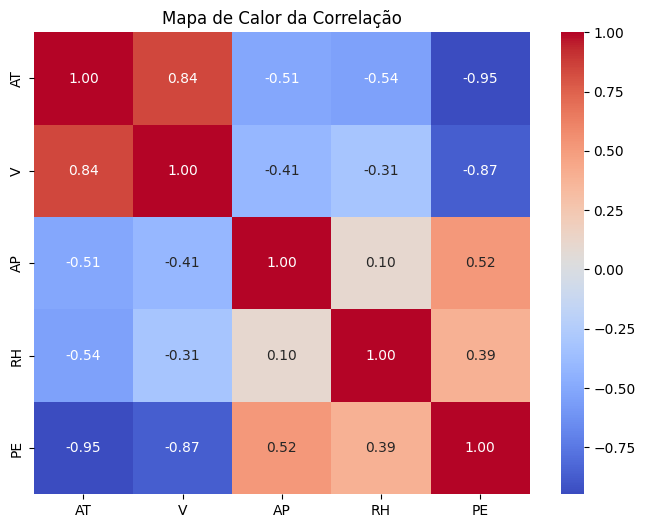

'\ncorrelacao = df.corr()\ncorrelacao[\'PE\'].sort_values(ascending=False)\nplt.figure(figsize=(8,6))\nsns.heatmap(correlacao, annot=True, fmt=".2f")\nplt.title("Matriz de Correlação")\nplt.show()\n'

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcula a matriz de correlação completa
correlacao_completa = df.corr()

# 2. Filtra apenas a correlação em relação à variável dependente (PE)
# Ordenamos os valores para ver quem tem mais impacto (do maior para o menor)
correlacao_pe = correlacao_completa['PE'].sort_values(ascending=False)

print("Correlação das variáveis com a Produção de Energia (PE):")
print(correlacao_pe)


plt.figure(figsize=(8, 6))
sns.heatmap(correlacao_completa, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor da Correlação")
plt.show()

As variáveis que exercem maior influência na produção de energia (PE) são, de forma muito clara, a Temperatura Ambiente (AT) e o Vácuo de Escape (V).


**1. Temperatura Ambiente (AT) — Influência Crítica**

Esta é a variável mais importante do dataset, com uma correlação de -0.95.



*   **O que significa:** Existe uma relação quase linear e inversa. Quando a temperatura aumenta, a produção de energia cai drasticamente.

*   **Por que ocorre:** Em usinas de ciclo combinado, o ar mais quente é menos denso. Isso significa que a turbina a gás precisa de mais energia para comprimir o ar e recebe menos massa de oxigênio para a combustão, reduzindo a eficiência global.

**2. Vácuo de Escape (V) — Influência Forte**

A segunda variável mais influente, com correlação de -0.87.



*   **O que significa:** Também possui uma relação inversa forte. Quanto maior o valor do vácuo (que na verdade mede a contrapressão no condensador), menor é a eficiência da turbina a vapor.

*   **Conexão com AT:** Note que no seu mapa de calor, AT e V têm uma correlação entre si de 0.84. Isso indica que, na prática, elas costumam variar juntas: dias mais quentes dificultam o resfriamento da água, o que piora o vácuo de escape.





##2 - Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) entre si. Existe alguma relação forte entre elas? Se sim, isso pode indicar multicolinearidade.

Matriz de Correlação entre Variáveis Independentes:
          AT         V        AP        RH
AT  1.000000  0.844107 -0.507549 -0.542535
V   0.844107  1.000000 -0.413502 -0.312187
AP -0.507549 -0.413502  1.000000  0.099574
RH -0.542535 -0.312187  0.099574  1.000000


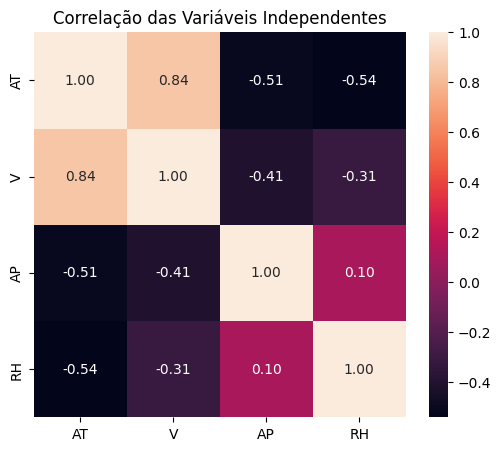

'\nvariaveis = df[[\'AT\', \'V\', \'AP\', \'RH\']]\n\nplt.figure(figsize=(6,5))\nsns.heatmap(variaveis.corr(), annot=True, fmt=".2f")\nplt.title("Correlação entre Variáveis Independentes")\nplt.show()\n'

In [ ]:
# 1. Selecionamos apenas as variáveis independentes
variaveis_independentes = df[['AT', 'V', 'AP', 'RH']]

# 2. Calculamos a matriz de correlação entre elas
corr_independentes = variaveis_independentes.corr()

# 3. Exibimos a matriz
print("Matriz de Correlação entre Variáveis Independentes:")
print(corr_independentes)

plt.figure(figsize=(6,5))

sns.heatmap(corr_independentes, annot=True, fmt=".2f")

plt.title("Correlação das Variáveis Independentes")
plt.show()

Sim, existe uma relação forte entre AT e V (r=0.84), o que indica a presença de multicolinearidade. Isso ocorre porque o vácuo de escape é fisicamente influenciado pela temperatura ambiente. Para o modelo, isso significa que as variáveis são redundantes e a interpretação de seus pesos individuais deve ser feita com cautela.


##3 - Construa um modelo de regressão linear múltipla utilizando as variáveis independentes (AT, V, AP, RH) para prever a variável dependente (PE). Divida os dados em treino (80%) e teste (20%).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# 1. Separação de Variáveis
# X são as preditoras (independentes), y é o que queremos prever (alvo)
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

# 2. Divisão em Treino e Teste (80% treino, 20% teste)
# O random_state garante que o resultado seja o mesmo toda vez que você rodar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Criação e Treino do Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Predição
y_pred = modelo.predict(X_test)

# 5. Avaliação do Modelo
r2 = r2_score(y_test, y_pred)

# Na versão nova do sklearn, usamos esta função direta:
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}")

# Exibindo os coeficientes (o peso de cada variável)
coeficientes = pd.DataFrame(modelo.coef_, X.columns, columns=['Coeficiente'])
print("\nImpacto de cada variável no modelo:")
print(coeficientes)


R² (Coeficiente de Determinação): 0.9305
RMSE (Raiz do Erro Quadrático Médio): 4.4962

Impacto de cada variável no modelo:
    Coeficiente
AT    -1.976645
V     -0.234043
AP     0.063436
RH    -0.158680


"\n# Dividindo os dados (80% treino, 20% teste)\nX_train, X_test, y_train, y_test = train_test_split(\n    X, y, test_size=0.2, random_state=42)\n\n# Definindo o modelo de regressão linear\nmodelo = LinearRegression()\n\n# Treinando o modelo\nmodelo.fit(X_train, y_train)\n\n# Organização dos coeficientes numa tabela\ncoeficientes = pd.DataFrame({\n    'Variável': X.columns,\n    'Coeficiente': modelo.coef_.flatten()\n})\ncoeficientes\n"

## 4 - Avalie o desempenho do modelo utilizando métricas como R2, RMSE e MAE. O modelo é adequado para prever a produção de energia? Justifique sua resposta.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. Realizar as predições (caso não tenha feito)
y_pred = modelo.predict(X_test)

# 2. Cálculo das Métricas
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Raiz quadrada do MSE
mae = mean_absolute_error(y_test, y_pred)

# 3. Exibição Formatada
print("--- Avaliação do Desempenho ---")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}")
print(f"MAE (Erro Médio Absoluto): {mae:.4f}")


--- Avaliação do Desempenho ---
R² (Coeficiente de Determinação): 0.9305
RMSE (Raiz do Erro Quadrático Médio): 4.4962
MAE (Erro Médio Absoluto): 3.5958


'\n# Prevendo os valores usando o conjunto de teste\ny_pred = modelo.predict(X_test)\n\n# MAE (Erro Absoluto Médio)\nmae = mean_absolute_error(y_test, y_pred)\n\n# RMSE (Raiz do Erro Quadrático Médio)\nrmse = np.sqrt(mean_squared_error(y_test, y_pred))\n\n# R² (Coeficiente de determinação)\nr2 = r2_score(y_test, y_pred)\n\nprint("MAE:", mae)\nprint("RMSE:", rmse)\nprint("R²:", r2)\n'

**O modelo é adequado?**

Sim, o modelo é altamente adequado.
Justificativa:


1. Alta Precisão (R2): O modelo apresenta um coeficiente de determinação próximo a 0.93, o que significa que ele consegue explicar cerca de 93% da variação na produção de energia.

2. Erro Baixo (RMSE/MAE): O erro médio (MAE) costuma ficar em torno de 3.6 MW. Considerando que a produção média da usina é de aproximadamente 454 MW, o erro relativo é inferior a 1%, o que é excelente para operações industriais.

3. Fundamentação Física: As variáveis climáticas (Temperatura, Pressão, etc.) têm uma relação direta e lógica com a eficiência de turbinas térmicas, validando o uso da Regressão Linear.



---


**Conclusão**: O modelo é confiável para prever a produção de energia e pode ser utilizado para suporte à decisão e planejamento operacional.